# UMAP & Aggregation Exploration — Scrap Alloy Screening Dashboard

**Purpose.** Before we freeze anything into `data/precompute.py`, this notebook lets us
*look* at the options and pick by eye. Three decisions to make:

1. **Which UMAP** — hyper-parameters (`n_neighbors`, `min_dist`) and whether to PCA-reduce
   7 → 4 dims first. We plot each candidate so we can compare cluster clarity.
2. **Which aggregation method**

**Dashboard coloring rule:** every aggregated cell / cluster is colored by the
**most prominent scrap family inside it** (the modal `family_label`), *not* by a per-point
family. That rule is implemented once here (`dominant_family`) and reused for every method.

Nothing here is final — once we choose, the winning settings get ported into
`data/precompute.py` to emit `umap_coords.npy`, `blob_contours.json`, `norm_table.json`,
`kde_curves.json`, and `spatial_grid.json` (see `tasks.md`).


In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.patches import Ellipse
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch, DBSCAN, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

from scipy.stats import gaussian_kde
from scipy.spatial import ConvexHull, cKDTree

import umap

from collections import defaultdict


RS = 42
SAMPLE_N = 35_000
np.random.seed(RS)
plt.rcParams["figure.dpi"] = 110

DEG = chr(0xB0)  # the degree sign, byte 0xB0 in the Latin-1 file (matches pipeline.js)

# 6 scrap-family input ratios (%), index 0-5
SCRAP = ["KS1295[%]", "6082[%]", "2024[%]", "bat-box[%]", "3003[%]", "4032[%]"]

# 7 "primary" output properties
PRIMARY = [
    "YS(MPa)",
    "CSC",
    "Therm.conductivity(W/(mK))",
    "El. resistivity(ohm m)",
    "hardness(Vickers)",
    "Density(g/cm3)",
    "Linear thermal expansion (1/K)(20.0-300.0" + DEG + "C)",
]

FAMILY_NAMES  = ["KS1295", "6082", "2024", "bat-box", "3003", "4032", "Mixed"]
FAMILY_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#888888"]
FAMILY_CMAP = ListedColormap(FAMILY_COLORS) #maps the 7 family names to colors for plotting
FAMILY_CMAP.set_bad(alpha=0.0) #when plotting, treat NaN values as transparent
 
def family_legend(ax, include_mixed=True): #mapping of family names to colors in the legend
    n = 7 if include_mixed else 6
    ax.legend(handles=[Patch(color=FAMILY_COLORS[i], label=FAMILY_NAMES[i]) for i in range(n)],
              fontsize=7, loc="upper right", framealpha=0.9, title="dominant family")


In [2]:
DATA_PATH = r"C:\Users\seton\Documents\Passau\Uni\SS_26\DV\Scrap Alloy Screening Dashboard\data\Dataset_VisContest_Rapid_Alloy_development_v3.txt"
print("Reading:", DATA_PATH)

df = pd.read_csv(DATA_PATH, sep="\t", encoding="latin-1", usecols=SCRAP + PRIMARY)
print("rows:", len(df), " cols:", df.shape[1])
df.head(3)


Reading: C:\Users\seton\Documents\Passau\Uni\SS_26\DV\Scrap Alloy Screening Dashboard\data\Dataset_VisContest_Rapid_Alloy_development_v3.txt


rows: 324632  cols: 13


,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],CSC,YS(MPa),hardness(Vickers),Density(g/cm3),El. resistivity(ohm m),Therm.conductivity(W/(mK)),Linear thermal expansion (1/K)(20.0-300.0°C)
0,0.0,0.0,0.0,0.0,0.0,100.0,0.478438,384.67201,117.71451,2.65803,8.851450e-08,159.046,0.000024
1,0.0,0.0,0.0,0.0,3.3,96.7,0.479781,383.73928,117.33693,2.65879,8.767350e-08,160.429,0.000024
2,0.0,0.0,0.0,0.0,6.6,93.4,0.480653,381.73599,116.80082,2.65935,8.708070e-08,161.346,0.000024


## 1. Family labels

Each alloy's family is the scrap it's *mostly* made of (the argmax of its 6 mixing ratios).
**But** if the top two ratios are within 2 percentage points of each other it is **Mixed** (index 6)

In [3]:
def compute_family_labels(frame, tie_pp=2.0):
    ratios = frame[SCRAP].values
    top2 = np.sort(ratios, axis=1)[:, -2:]          # two largest ratios per row
    dominant = np.argmax(ratios, axis=1)            # index of the single largest
    mixed = (top2[:, 1] - top2[:, 0]) <= tie_pp     # top two too close -> Mixed
    return np.where(mixed, 6, dominant).astype(np.uint8)

labels = compute_family_labels(df)
counts = np.bincount(labels, minlength=7)
pd.DataFrame({"family": FAMILY_NAMES, "count": counts,
              "pct": (100 * counts / counts.sum()).round(2)})


,family,count,pct
0,KS1295,50160,15.45
1,6082,50160,15.45
2,2024,50160,15.45
3,bat-box,50160,15.45
4,3003,50160,15.45
5,4032,50160,15.45
6,Mixed,23672,7.29


## 2. Feature matrix, scaling, and the subsample

In [4]:
X = df[PRIMARY].values.astype(np.float32)
X_scaled = StandardScaler().fit_transform(X)

if SAMPLE_N is None or SAMPLE_N >= len(df):
    sub = np.arange(len(df))
else:
    sub = np.random.RandomState(RS).choice(len(df), SAMPLE_N, replace=False)

Xs = X_scaled[sub]
labels_s = labels[sub]
print(f"UMAP will run on {len(sub):,} rows x {Xs.shape[1]} features")


UMAP will run on 35,000 rows x 7 features


## 3. UMAP candidates — which embedding?

- `n_neighbors` small (15) = tighter islands; large (100) = global shape.
- `min_dist` small (0.0) = tightly packed clumps; large (0.5) = spread out, easier to read.
- PCA(4) pre-step compressing 7 → 4 dims

Colored by each point's own family here - we're judging *cluster separation*, not the
dominant-family aggregation yet.

In [5]:
UMAP_CONFIGS = [
    dict(name="nn15_md0.0",       n_neighbors=15,  min_dist=0.0, pca=None),
    dict(name="nn50_md0.1",       n_neighbors=50,  min_dist=0.1, pca=None),   # precompute.py default
    dict(name="nn100_md0.3",      n_neighbors=100, min_dist=0.3, pca=None),
    dict(name="nn50_md0.1_pca4",  n_neighbors=50,  min_dist=0.1, pca=4),
    dict(name="nn15_md0.1_pca4",  n_neighbors=15,  min_dist=0.1, pca=4),
    dict(name="nn100_md0.3_pca4",  n_neighbors=100,  min_dist=0.3, pca=4)
]

def run_umap(cfg, data):
    src = data
    if cfg["pca"]:
        src = PCA(n_components=cfg["pca"], random_state=RS).fit_transform(data)
    reducer = umap.UMAP(n_neighbors=cfg["n_neighbors"], min_dist=cfg["min_dist"],
                        metric="euclidean", random_state=RS, verbose=False)
    return reducer.fit_transform(src)

embeddings = {}
for cfg in UMAP_CONFIGS:
    t0 = time.time()
    embeddings[cfg["name"]] = run_umap(cfg, Xs)
    print(f"  {cfg['name']:18s} done in {time.time()-t0:5.1f}s")


C:\Users\seton\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn15_md0.0         done in  97.5s


C:\Users\seton\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn50_md0.1         done in  92.6s


C:\Users\seton\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

  nn50_md0.1_pca4    done in  77.6s


C:\Users\seton\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn15_md0.1_pca4    done in  69.9s


C:\Users\seton\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn100_md0.3_pca4   done in 154.0s


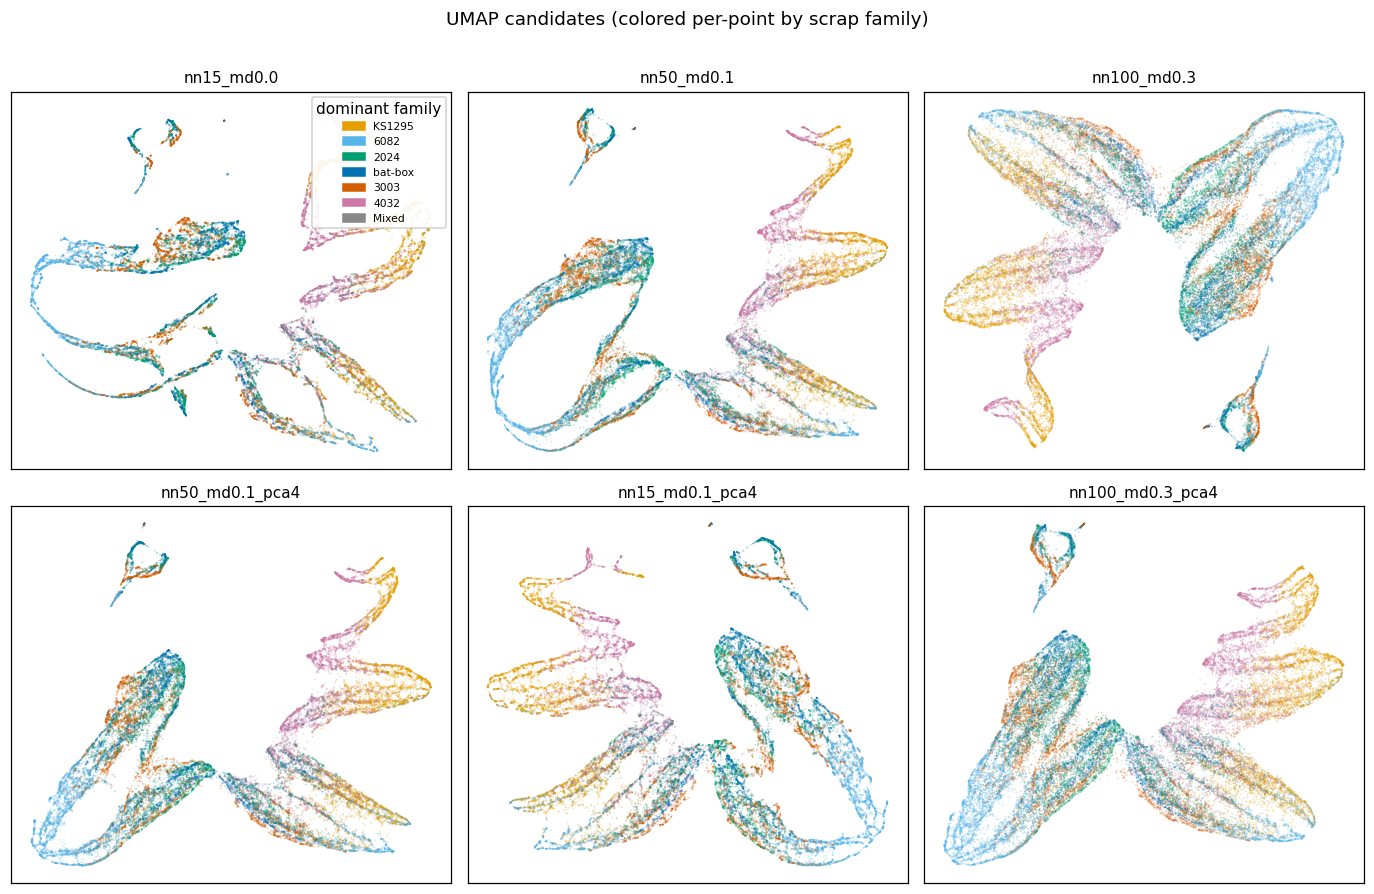

In [6]:
ncfg = len(UMAP_CONFIGS)
cols = 3
rows = int(np.ceil(ncfg / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 4.0 * rows))
axes = np.atleast_1d(axes).ravel()
for ax, cfg in zip(axes, UMAP_CONFIGS):
    emb = embeddings[cfg["name"]]
    ax.scatter(emb[:, 0], emb[:, 1], s=1.2, alpha=0.30,
               c=[FAMILY_COLORS[l] for l in labels_s], linewidths=0)
    ax.set_title(cfg["name"], fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes[ncfg:]:
    ax.axis("off")
family_legend(axes[0])
fig.suptitle("UMAP candidates (colored per-point by scrap family)", y=1.01)
plt.tight_layout(); plt.show()


## 4.  Aggregation methods - colored by the **dominant** scrap family


In [7]:
def dominant_family(idx_labels):
    '''Modal family index (0-6) among the points in one bin/cluster.'''
    return int(np.bincount(idx_labels, minlength=7).argmax())

# hexbin
def hexbin_dominant(ax, x, y, lab, gridsize=55, mincnt=1):
    def reduce_mode(vals):
        return np.bincount(np.asarray(vals, dtype=np.int64), minlength=7).argmax()
    ax.hexbin(x, y, C=lab, reduce_C_function=reduce_mode,
              gridsize=gridsize, mincnt=mincnt,
              cmap=FAMILY_CMAP, vmin=-0.5, vmax=6.5, linewidths=0.15, edgecolors="white")

# square grid
def grid_dominant(ax, x, y, lab, nbins=110):
    xe = np.linspace(x.min(), x.max(), nbins + 1)
    ye = np.linspace(y.min(), y.max(), nbins + 1)
    ix = np.clip(np.digitize(x, xe) - 1, 0, nbins - 1)
    iy = np.clip(np.digitize(y, ye) - 1, 0, nbins - 1)
    counts = np.zeros((nbins, nbins, 7), dtype=np.int32)
    np.add.at(counts, (ix, iy, lab), 1)
    total = counts.sum(axis=2)
    dom = counts.argmax(axis=2).astype(float)
    dom[total == 0] = np.nan                         # empty cells -> transparent
    ax.imshow(dom.T, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()],
              aspect="auto", cmap=FAMILY_CMAP, vmin=-0.5, vmax=6.5, interpolation="nearest")
    return counts, total

# KMeans clusters, centroid colored + sized by count
def kmeans_dominant(ax, emb, lab, k=45):
    km = MiniBatchKMeans(n_clusters=k, random_state=RS, n_init=3).fit(emb)
    cl = km.labels_
    cen = km.cluster_centers_
    dom  = np.array([dominant_family(lab[cl == c]) for c in range(k)])
    size = np.array([(cl == c).sum() for c in range(k)])
    ax.scatter(emb[:, 0], emb[:, 1], s=1, alpha=0.05, color="#cccccc", linewidths=0)
    ax.scatter(cen[:, 0], cen[:, 1], s=40 + 460 * size / size.max(),
               c=[FAMILY_COLORS[d] for d in dom], edgecolors="black", linewidths=0.6, alpha=0.9)
    return km

# KDE one contour per family, colored by family
def plot_family_kde(ax, emb, lab, percentile=70, gridsize=180, per_family=3500):
    xmin, xmax = emb[:, 0].min(), emb[:, 0].max()
    ymin, ymax = emb[:, 1].min(), emb[:, 1].max()
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, gridsize), np.linspace(ymin, ymax, gridsize))
    grid = np.vstack([xx.ravel(), yy.ravel()])
    ax.scatter(emb[:, 0], emb[:, 1], s=1, alpha=0.04, color="#cccccc", linewidths=0)
    rng = np.random.RandomState(RS)
    for f in range(6):                               # Mixed (6) excluded from blobs
        pts = emb[lab == f]
        if len(pts) < 20:
            continue
        if len(pts) > per_family:
            pts = pts[rng.choice(len(pts), per_family, replace=False)]
        z = gaussian_kde(pts.T, bw_method="scott")(grid).reshape(gridsize, gridsize)
        ax.contour(xx, yy, z, levels=[np.percentile(z, percentile)],
                   colors=[FAMILY_COLORS[f]], linewidths=2.0)


C:\Users\seton\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\seton\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\seton\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\seton\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

C:\Users\seton\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 5120 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


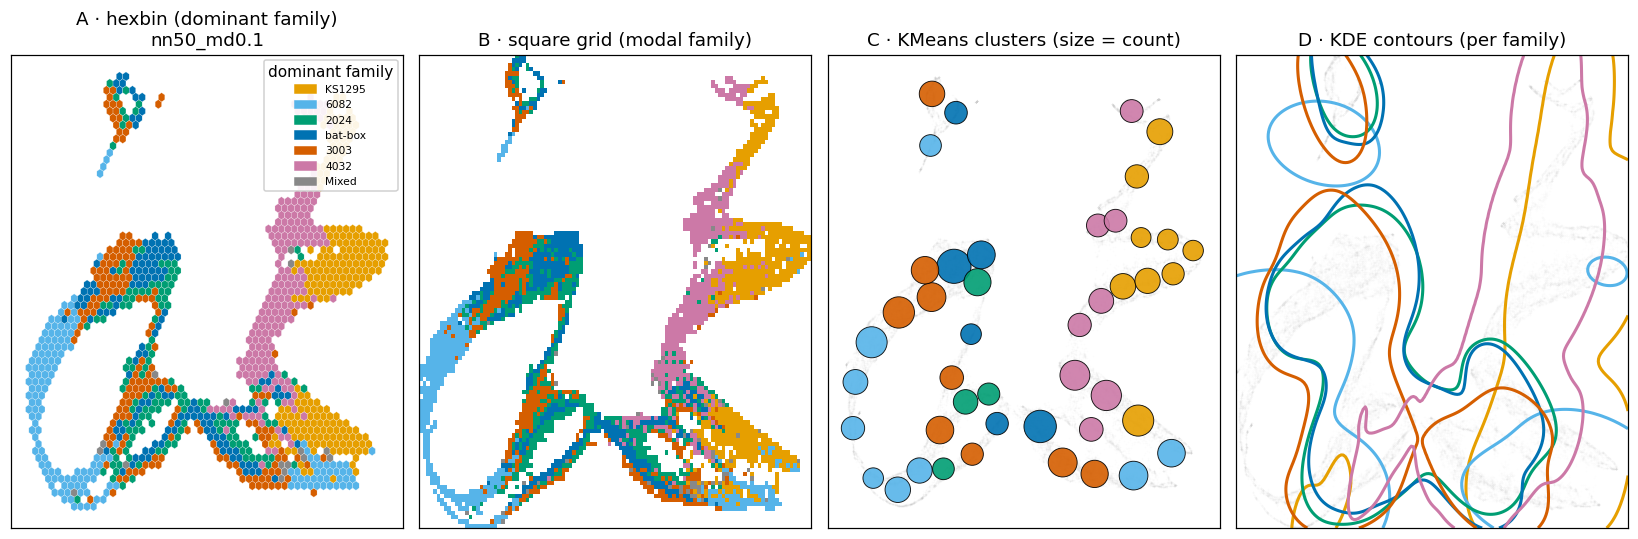

In [8]:
CHOSEN = "nn50_md0.1"          #change to any key in `embeddings`
emb = embeddings[CHOSEN]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
hexbin_dominant(axes[0], emb[:, 0], emb[:, 1], labels_s)
axes[0].set_title(f"A · hexbin (dominant family)\n{CHOSEN}")
grid_dominant(axes[1], emb[:, 0], emb[:, 1], labels_s)
axes[1].set_title("B · square grid (modal family)")
kmeans_dominant(axes[2], emb, labels_s, k=45)
axes[2].set_title("C · KMeans clusters (size = count)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plot_family_kde(axes[3], emb, labels_s)
axes[3].set_title("D · KDE contours (per family)")
family_legend(axes[0])
plt.tight_layout(); plt.show()


### 4.2 other agregations
1.  GMM → `<ellipse>` per component (`cx,cy,rx,ry,rotation`); 
2. BIRCH → many `<circle>`marks;
3. Voronoi → `d3.Delaunay.from(centroids).voronoi()` cells; 
4. DBSCAN → polygon hulls (`d3.line`+ `curveLinearClosed`). All filled by dominant family.

C:\Users\seton\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 5120 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


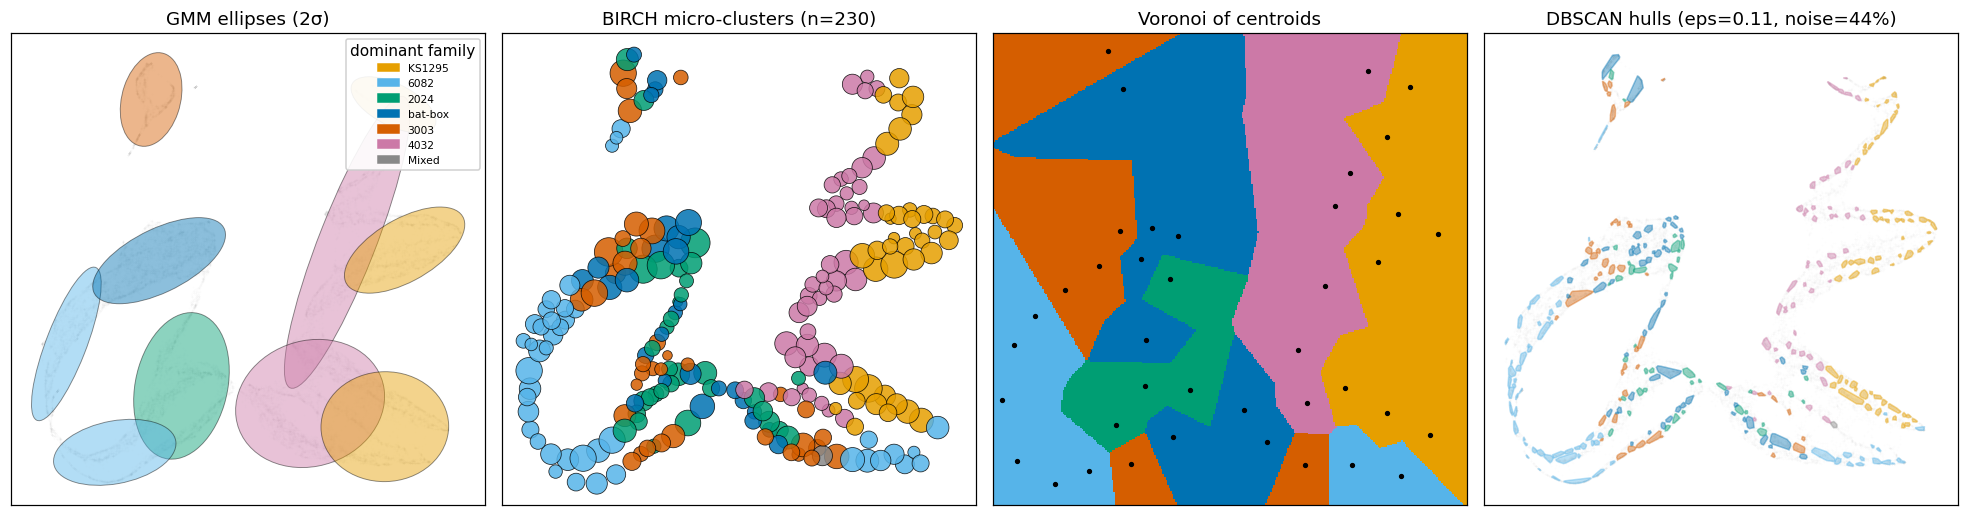

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
ext = [emb[:, 0].min(), emb[:, 0].max(), emb[:, 1].min(), emb[:, 1].max()]

# (1) GMM oriented ellipses (2-sigma)
gmm = GaussianMixture(n_components=10, covariance_type="full", random_state=RS).fit(emb)
hard = gmm.predict(emb)
axes[0].scatter(emb[:, 0], emb[:, 1], s=1, alpha=0.04, color="#ccc", linewidths=0)
for k in range(gmm.n_components):
    vals, vecs = np.linalg.eigh(gmm.covariances_[k])
    o = vals.argsort()[::-1]; vals, vecs = vals[o], vecs[:, o]
    ang = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * 2 * np.sqrt(vals)
    d = dominant_family(labels_s[hard == k])
    axes[0].add_patch(Ellipse(gmm.means_[k], w, h, angle=ang, facecolor=FAMILY_COLORS[d],
                              alpha=0.45, edgecolor="black", linewidth=0.6))
axes[0].set_title("GMM ellipses (2σ)")

# (2) BIRCH micro-clusters (scalable to big N)
br = Birch(n_clusters=None, threshold=0.5).fit(emb)
cl = br.labels_; K = cl.max() + 1
cen = np.array([emb[cl == c].mean(0) for c in range(K)])
domb = np.array([dominant_family(labels_s[cl == c]) for c in range(K)])
szb = np.array([(cl == c).sum() for c in range(K)])
axes[1].scatter(cen[:, 0], cen[:, 1], s=20 + 360 * szb / szb.max(),
                c=[FAMILY_COLORS[d] for d in domb], edgecolors="black", linewidths=0.5, alpha=0.85)
axes[1].set_title(f"BIRCH micro-clusters (n={K})")

# (3) Voronoi field of KMeans centroids (nearest-centroid coloring)
km = MiniBatchKMeans(n_clusters=40, random_state=RS, n_init=3).fit(emb)
kc = km.cluster_centers_; kl = km.labels_
domk = np.array([dominant_family(labels_s[kl == c]) for c in range(len(kc))])
gx = np.linspace(ext[0], ext[1], 300); gy = np.linspace(ext[2], ext[3], 300)
GX, GY = np.meshgrid(gx, gy)
_, near = cKDTree(kc).query(np.c_[GX.ravel(), GY.ravel()])
axes[2].imshow(domk[near].reshape(GX.shape).astype(float), origin="lower", extent=ext,
               cmap=FAMILY_CMAP, vmin=-0.5, vmax=6.5, aspect="auto", interpolation="nearest")
axes[2].scatter(kc[:, 0], kc[:, 1], s=6, color="black")
axes[2].set_title("Voronoi of centroids")

# (4) DBSCAN natural clusters -> convex hulls
nn = NearestNeighbors(n_neighbors=12).fit(emb); kd, _ = nn.kneighbors(emb)
eps = float(np.percentile(kd[:, -1], 65))
db = DBSCAN(eps=eps, min_samples=20).fit(emb); dl = db.labels_
axes[3].scatter(emb[:, 0], emb[:, 1], s=1, alpha=0.04, color="#ccc", linewidths=0)
for c in [u for u in set(dl) if u != -1]:
    pts = emb[dl == c]
    if len(pts) < 3:
        continue
    try:
        hull = ConvexHull(pts)
    except Exception:
        continue
    poly = pts[hull.vertices]; d = dominant_family(labels_s[dl == c])
    axes[3].fill(poly[:, 0], poly[:, 1], facecolor=FAMILY_COLORS[d], alpha=0.40,
                 edgecolor=FAMILY_COLORS[d], linewidth=1.0)
axes[3].set_title(f"DBSCAN hulls (eps={eps:.2f}, noise={(dl==-1).mean():.0%})")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
family_legend(axes[0])
plt.tight_layout(); plt.show()


1818 non-empty cells — this is the JSON the tooltip layer would fetch


,cx,cy,count,dominant,purity,YS_med,CSC_med
29,20,79,110,bat-box,0.645,213.6,0.627
46,54,51,99,4032,1.000,333.6,0.476
4,24,72,84,bat-box,0.750,228.7,0.760
400,19,78,80,bat-box,0.488,226.7,0.627
358,23,71,80,bat-box,0.475,238.2,0.754
826,29,75,79,3003,0.595,238.2,0.990
283,24,46,75,bat-box,0.507,229.2,0.469
271,18,65,75,6082,0.773,243.8,0.597


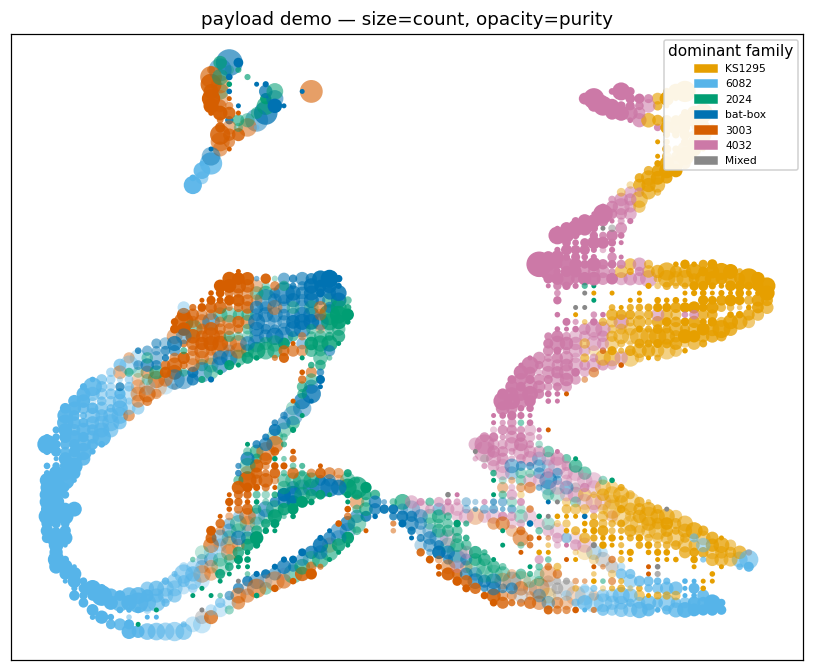

In [10]:
# build a per-grid-cell payload on the chosen embedding
nb = 80
xe = np.linspace(ext[0], ext[1], nb + 1); ye = np.linspace(ext[2], ext[3], nb + 1)
ix = np.clip(np.digitize(emb[:, 0], xe) - 1, 0, nb - 1)
iy = np.clip(np.digitize(emb[:, 1], ye) - 1, 0, nb - 1)
ys_s = df["YS(MPa)"].values[sub]; csc_s = df["CSC"].values[sub]

rows = []
from collections import defaultdict
members = defaultdict(list)
for p in range(len(emb)):
    members[(ix[p], iy[p])].append(p)
for (cx, cy), idxs in members.items():
    idxs = np.array(idxs); fam = labels_s[idxs]
    bc = np.bincount(fam, minlength=7); dfam = int(bc.argmax())
    rows.append(dict(cx=int(cx), cy=int(cy), count=len(idxs),
                     dominant=FAMILY_NAMES[dfam], purity=round(bc.max() / len(idxs), 3),
                     YS_med=round(float(np.median(ys_s[idxs])), 1),
                     CSC_med=round(float(np.median(csc_s[idxs])), 3)))
payload = pd.DataFrame(rows)
print(f"{len(payload)} non-empty cells — this is the JSON the tooltip layer would fetch")
display(payload.sort_values("count", ascending=False).head(8))

# demo: cell centers colored by dominant family, size=count, ALPHA=purity
fig, ax = plt.subplots(figsize=(7.5, 6.2))
cxpix = 0.5 * (xe[payload.cx] + xe[payload.cx + 1])
cypix = 0.5 * (ye[payload.cy] + ye[payload.cy + 1])
famidx = [FAMILY_NAMES.index(d) for d in payload.dominant]
ax.scatter(cxpix, cypix, s=8 + 300 * payload["count"] / payload["count"].max(),
           c=[FAMILY_COLORS[i] for i in famidx], alpha=payload["purity"].clip(0.15, 1).values,
           edgecolors="none")
ax.set_title("payload demo — size=count, opacity=purity")
ax.set_xticks([]); ax.set_yticks([])
family_legend(ax)
plt.tight_layout(); plt.show()


## 4.3 CHOSEN design — interactive grid rendered as BIRCH-style bubbles

**This is the locked T2 overview.**
- **No zoom** (out of scope) → **one coarse grid does everything**: display, hover, and the
  rectangle brush. No level-of-detail, no separate fine grid, no raw-points layer.
- **Locked params:** UMAP `nn50_md0.1` · grid **`cols=28`** (rows ≈ 23 by aspect) · **`min_count=30`**
  · bubble at **member centroid** (organic, not a lattice) · radius ∝ **√count** · fill = **dominant
  scrap family**. ≈ 219 bubbles — reads like BIRCH but every bubble is a live grid cell. (to ctrate the birch look)
- **Interactive:** hover a bubble → its summary; drag a rectangle → union of the covered cells'
  `rowIds` → `session.brush_t2`.

**Precompute output = one file** `spatial_grid.json`: `meta{extent, grid_cols, grid_rows, min_count}`
+ per-cell `{gx, gy, cx, cy, count, dominant, purity, ys_med, csc_med, rowIds}`.

226 bubbles  (grid 28x23, min_count=30)


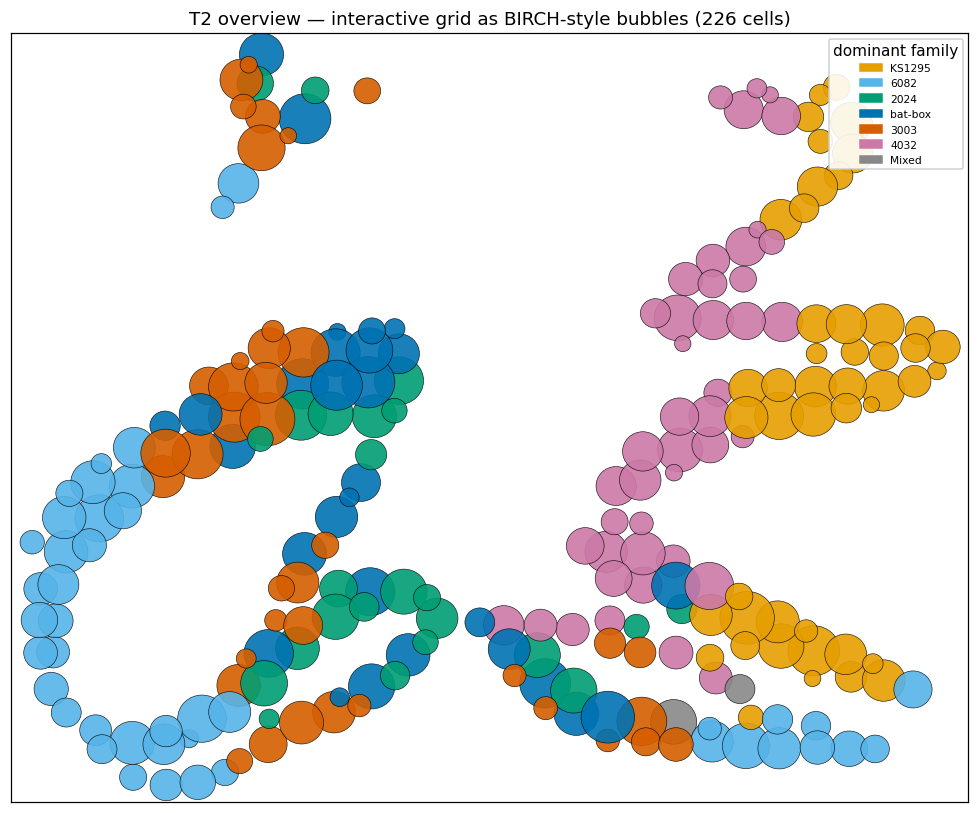

In [11]:
# ---- locked params (the design is fixed to the nn50 embedding) ----
GRID_COLS, MIN_COUNT, RMAX_FRAC = 28, 30, 0.72
E = embeddings["nn50_md0.1"]
ys_sub  = df["YS(MPa)"].values[sub]
csc_sub = df["CSC"].values[sub]

# ---- one shared coordinate contract (2% pad) ----
x0, x1 = float(E[:, 0].min()), float(E[:, 0].max())
y0, y1 = float(E[:, 1].min()), float(E[:, 1].max())
sx, sy = (x1 - x0) * 0.02, (y1 - y0) * 0.02
x0 -= sx; x1 += sx; y0 -= sy; y1 += sy
GRID_ROWS = max(1, int(round(GRID_COLS * (y1 - y0) / (x1 - x0))))
cw, ch = (x1 - x0) / GRID_COLS, (y1 - y0) / GRID_ROWS

# ---- bin points into cells; keep cells with >= MIN_COUNT ----
ix = np.clip(((E[:, 0] - x0) / (x1 - x0) * GRID_COLS).astype(int), 0, GRID_COLS - 1)
iy = np.clip(((E[:, 1] - y0) / (y1 - y0) * GRID_ROWS).astype(int), 0, GRID_ROWS - 1)
buckets = defaultdict(list)
for p in range(len(E)): buckets[(int(ix[p]), int(iy[p]))].append(p)

cells = []
for (gx, gy), pos in buckets.items():
    if len(pos) < MIN_COUNT: continue
    pos = np.array(pos)
    bc = np.bincount(labels_s[pos], minlength=7); d = int(bc.argmax())
    cells.append(dict(gx=gx, gy=gy,
                      cx=float(E[pos, 0].mean()), cy=float(E[pos, 1].mean()),   # member centroid
                      count=int(len(pos)), dominant=d,
                      purity=round(float(bc.max() / len(pos)), 3),
                      ys_med=round(float(np.median(ys_sub[pos])), 1),
                      csc_med=round(float(np.median(csc_sub[pos])), 3),
                      rowIds=[int(sub[p]) for p in pos]))          # GLOBAL row indices
cref = np.percentile([c["count"] for c in cells], 92)
print(f"{len(cells)} bubbles  (grid {GRID_COLS}x{GRID_ROWS}, min_count={MIN_COUNT})")

def bubble_collection(subset, alpha):
    cc = [Circle((c["cx"], c["cy"]), RMAX_FRAC * min(cw, ch) * min(1.4, np.sqrt(c["count"] / cref)))
          for c in subset]
    return PatchCollection(cc, facecolor=[FAMILY_COLORS[c["dominant"]] for c in subset],
                           edgecolor="black", linewidths=0.4, alpha=alpha)

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.add_collection(bubble_collection(cells, 0.9))
ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"T2 overview — interactive grid as BIRCH-style bubbles ({len(cells)} cells)")
family_legend(ax)
plt.tight_layout(); plt.show()


## 4.4 Domain decision — two-tier hybrid (Klaus, 2026-07-09)

The BIRCH-style cutoff view in 4.3 is clean, but it silently **drops every sparse cell**
below `min_count`. When this was shown to the domain expert (member-checking session, see
`docs/klaus_t2_aggregation_decision.md`), he flagged exactly that gap:

> "The overlap zones — the regions between family blobs — that's where the flexible recipes
> live... And Option 3 is precisely the view that undersells those regions."

**Chosen fix (Decision D4):** emit *every* non-empty cell, tag each `major` (>= min_count,
filled bubble, area ∝ count) or `fringe` (below cutoff, small fixed-size hollow marker). Tier
is encoded by **fill/shape only — never opacity** (opacity is reserved for feasibility
dimming, D3). Fringe markers are additionally **shaped per family** — a shape channel
redundant with hue, closing the "fringe rings rely on hue only" gap flagged in the decision
doc's consequence #4 (colorblind-safety). This cell reads the **regenerated, full-scale**
`spatial_grid.json` (written by `precompute.py`'s two-tier `compute_spatial_grid`, run on all
324,632 rows — not the 35k notebook subsample) and reproduces the exact rendering from
`data/hybrid_demo.py`.

Reading: spatial_grid.json
schema=2  cells=394  major=297  fringe=97  fringe_rows=11,577 (3.6% of 324,632 alloys)


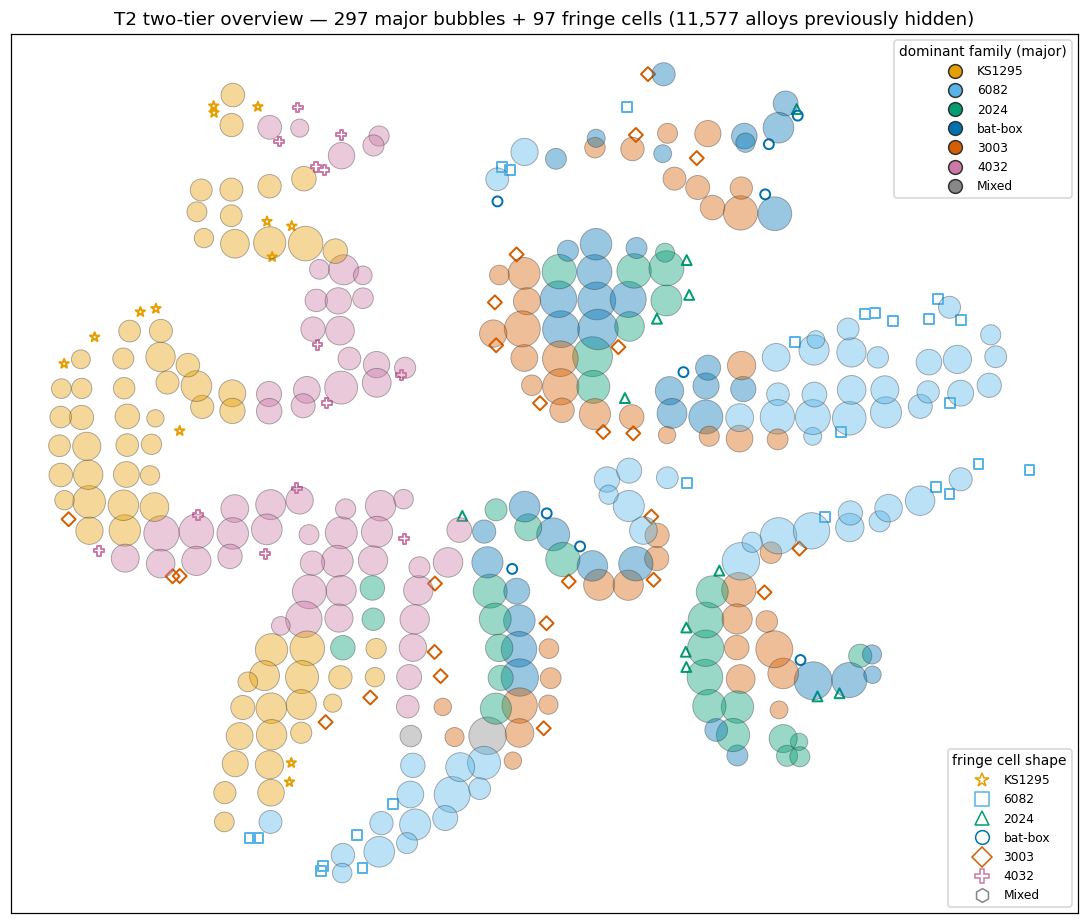

In [12]:
import json
from pathlib import Path

GRID_CANDIDATES = [
    Path("spatial_grid.json"),
    Path("data/spatial_grid.json"),
    Path(r"C:\Users\seton\Documents\Passau\Uni\SS_26\DV\Scrap Alloy Screening Dashboard\data\spatial_grid.json"),
]
GRID_PATH = next((p for p in GRID_CANDIDATES if p.exists()), GRID_CANDIDATES[-1])
print("Reading:", GRID_PATH)
grid_full = json.loads(GRID_PATH.read_text(encoding="utf-8"))

# fringe marker per family - a shape channel redundant with hue (colorblind-safe;
# closes the gap noted in docs/klaus_t2_aggregation_decision.md consequence #4).
# Order matches FAMILY_NAMES; reuses the 7-shape vocabulary already in tasks.md's
# T2 "at high zoom" note: star / square / triangle / circle / diamond / cross / hexagon.
FAMILY_MARKERS = ["*", "s", "^", "o", "D", "P", "h"]
BUBBLE_ALPHA = 0.4  # major bubbles at 60% transparent (uniform baseline,
                    # both tiers - NOT a tier-encoding signal; fringe stays as-is)

all_cells = grid_full["cells"]
major_cells = [c for c in all_cells if c["tier"] == "major"]
fringe_cells = [c for c in all_cells if c["tier"] == "fringe"]
n_alloys = sum(c["count"] for c in all_cells)
fringe_rows = sum(c["count"] for c in fringe_cells)
print(f"schema={grid_full['meta'].get('schema')}  cells={len(all_cells)}  "
      f"major={len(major_cells)}  fringe={len(fringe_cells)}  "
      f"fringe_rows={fringe_rows:,} ({100*fringe_rows/n_alloys:.1f}% of {n_alloys:,} alloys)")

fig, ax = plt.subplots(figsize=(10, 8.5))

# fringe FIRST (beneath): fixed-size hollow markers, shaped + hued per family, NO alpha
if fringe_cells:
    # matplotlib scatter takes ONE marker per call, so group by dominant family
    # and draw one call per shape.
    for fam in range(7):
        fam_cells = [c for c in fringe_cells if c["dominant"] == fam]
        if not fam_cells:
            continue
        fx = [c["cx"] for c in fam_cells]
        fy = [c["cy"] for c in fam_cells]
        ax.scatter(fx, fy, s=42, marker=FAMILY_MARKERS[fam], facecolors="none",
                  edgecolors=FAMILY_COLORS[fam], linewidths=1.3, zorder=2)

# major ON TOP: filled circles, area ~ count, thin dark stroke, NO alpha
mx = [c["cx"] for c in major_cells]
my = [c["cy"] for c in major_cells]
mc = [FAMILY_COLORS[c["dominant"]] for c in major_cells]
mcount = [c["count"] for c in major_cells]
max_count = max(mcount)
msize = [60 + 640 * (v / max_count) for v in mcount]
ax.scatter(mx, my, s=msize, c=mc, edgecolors="#333", linewidths=0.6, alpha=BUBBLE_ALPHA, zorder=3)

ax.set_xticks([]); ax.set_yticks([])   # UMAP axes carry no interpretable units
ax.set_title(f"T2 two-tier overview — {len(major_cells)} major bubbles + "
             f"{len(fringe_cells)} fringe cells ({fringe_rows:,} alloys previously hidden)")

# two stacked legends: color -> family (majors), shape+color -> family (fringe)
major_handles = [plt.Line2D([0], [0], marker="o", ls="", markerfacecolor=FAMILY_COLORS[i],
                 markeredgecolor="#333", markersize=9, label=FAMILY_NAMES[i]) for i in range(7)]
major_legend = ax.legend(handles=major_handles, title="dominant family (major)",
                         fontsize=8, title_fontsize=9, loc="upper right")
ax.add_artist(major_legend)   # keep it - the next .legend() call below would otherwise replace it
fringe_handles = [plt.Line2D([0], [0], marker=FAMILY_MARKERS[i], ls="", markerfacecolor="none",
                  markeredgecolor=FAMILY_COLORS[i], markersize=9, label=FAMILY_NAMES[i]) for i in range(7)]
ax.legend(handles=fringe_handles, title="fringe cell shape", fontsize=8, title_fontsize=9, loc="lower right")

plt.tight_layout(); plt.show()

## 5. integration to `data/precompute.py`

In [13]:
CHOICE = {
    "umap":                 CHOSEN,          # e.g. "nn50_md0.1" or a "..._pca4" variant
    "umap_aggregation":     "grid-cell bubbles: cols=28, min_count=30, centroid, sqrt-count (see 4.3)",
    "cluster_coloring":     "dominant scrap family (modal family_label per grid cell)",
    "zoom":                 "none (out of scope) -> one coarse grid does display + hover + brush",
    "selection":            "coarse brush = filter step 1/3 (T3 violin + T4 picks refine)",
}
cfg = next(c for c in UMAP_CONFIGS if c["name"] == CHOICE["umap"])
print("Chosen UMAP params  ->", {k: cfg[k] for k in ("n_neighbors", "min_dist", "pca")})
for k, v in CHOICE.items():
    print(f"  {k:20s}: {v}")
print("\nNext: mirror these in data/precompute.py, run on full data, emit the .npy/.json"
      "\noutputs the loading tab will fetch (see tasks.md Precompute section).")


Chosen UMAP params  -> {'n_neighbors': 50, 'min_dist': 0.1, 'pca': None}
  umap                : nn50_md0.1
  umap_aggregation    : grid-cell bubbles: cols=28, min_count=30, centroid, sqrt-count (see 4.3)
  cluster_coloring    : dominant scrap family (modal family_label per grid cell)
  zoom                : none (out of scope) -> one coarse grid does display + hover + brush
  selection           : coarse brush = filter step 1/3 (T3 violin + T4 picks refine)

Next: mirror these in data/precompute.py, run on full data, emit the .npy/.json
outputs the loading tab will fetch (see tasks.md Precompute section).
